# Demo

## The Generator: Generation of graph-based Game Economies

* Generate a new and valid economy graph by providing a configuration dictionary ``conf``. Specify how many nodes of which types should be in the economy.
* There are some constraints to generate valid graphs e.g., there must be at least one source and one pool node! See paper for detailed information.

In [ ]:
from geevo.evolution.generator import EvolutionaryGraphGeneration
from geevo.evolution.balancer import Balancer
from geevo import nodes as n
from geevo.agent_simulation import Agent
from geevo.graph import Graph
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings('ignore')

# define config as input to control graph generation
conf = {
    n.Source: 3,
    n.RandomGate: 2,
    n.Pool: 4,
    n.Converter: 1
}

### [Alternatif] Automasi Ekstraksi Konfigurasi dari GDD

Sebagai alternatif dari pembentukan state `conf` secara manual di atas, sel berikut akan **mengotomatiskan** proses ekstraksi konfigurasi ekonomi langsung dari dokumen *Game Design Document* (PDF).

**Metode yang digunakan:**
- Ekstraksi teks dari PDF menggunakan library `fitz` (PyMuPDF) — lebih andal dan konsisten dibanding `PyPDF2`.
- Pencarian kata kunci (*Term Frequency*) yang relevan dengan masing-masing tipe node GEEvo.
- Normalisasi frekuensi menjadi distribusi proporsi jumlah node.

**Cara penggunaan:**
1. Jalankan sel di bawah ini.
2. Set `USE_GDD_CONF = True` untuk menggunakan konfigurasi dari GDD.
3. Ganti `gdd_path` ke file PDF GDD yang diinginkan (lihat daftar file di bawah).
4. Variabel `conf` akan **otomatis di-overwrite** dengan konfigurasi dari GDD.
5. Kemudian lanjutkan menjalankan sel Generator (`egg.run()`) seperti biasa.
6. Jika ingin kembali ke mode random/manual, cukup set `USE_GDD_CONF = False` atau skip sel ini.

**File GDD yang tersedia di folder `Gdd/`:**
- `MMORPG_GameDesign_v27.pdf`
- `VHS-Horror-Game-Design-Document.pdf`
- `Battle For Treasure.pdf`
- `Pierre_GDD.pdf`

In [ ]:
import os
from geevo.gdd_extractor import GDDGraphExtractor

# Set True untuk ekstraksi dari GDD PDF, False untuk pakai conf manual di atas.
USE_GDD_CONF = True

# Ganti ke salah satu file berikut:
#   'Gdd/MMORPG_GameDesign_v27.pdf'
#   'Gdd/VHS-Horror-Game-Design-Document.pdf'
#   'Gdd/Battle For Treasure.pdf'
#   'Gdd/Pierre_GDD.pdf'
gdd_path = 'Gdd/MMORPG_GameDesign_v27.pdf'

# Tampilkan daftar file PDF tersedia
gdd_dir = 'Gdd'
if os.path.isdir(gdd_dir):
    pdfs = sorted([f for f in os.listdir(gdd_dir) if f.lower().endswith(".pdf")])
    print("File GDD tersedia:")
    for pf in pdfs:
        marker = " <- (dipilih)" if f"{gdd_dir}/{pf}" == gdd_path else ""
        print(f"  {gdd_dir}/{pf}{marker}")

if USE_GDD_CONF:
    if not os.path.exists(gdd_path):
        print(f"[!] File tidak ditemukan: {gdd_path} — menggunakan conf manual.")
        USE_GDD_CONF = False
    else:
        extractor = GDDGraphExtractor(gdd_path, max_nodes=13)
        g = extractor.extract()   # ekstrak conf + jalankan EGG + buat Graph
        conf = extractor.conf
        for c in g.get_nodes_of(n.Converter):
            c.is_auto = False
        print("
[*] Graf berhasil dibangkitkan dari GDD. Lewati sel EGG di bawah.")
else:
    print("[MANUAL] Menggunakan conf manual. Jalankan sel EGG di bawah.")


In [ ]:
# Lewati sel ini jika USE_GDD_CONF = True (graf sudah dibangkitkan dari GDD)
if not USE_GDD_CONF:
    egg = EvolutionaryGraphGeneration(conf)
    egg.run()


In [ ]:
# Plot fitness EGG hanya jika menggunakan mode manual
if not USE_GDD_CONF:
    plt.figure(figsize=(4, 2))
    plt.plot(egg.fitness)


In [ ]:
# Buat graf dari hasil EGG (hanya jika mode manual)
if not USE_GDD_CONF:
    g = Graph(conf, egg.get_best())
    for c in g.get_nodes_of(n.Converter):
        c.is_auto = False

# Plot graf (selalu dijalankan)
g.plot()
# Catatan: bobot edge diinisialisasi acak — akan dioptimasi oleh Balancer


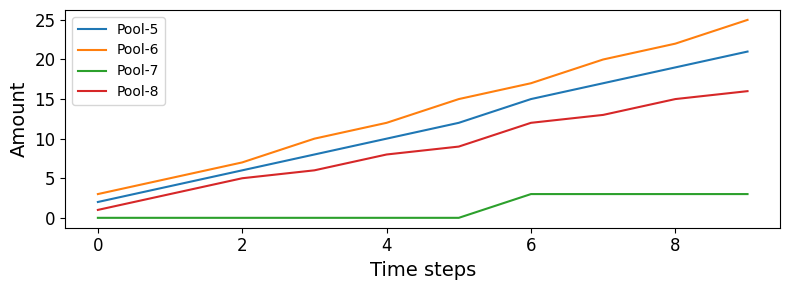

In [5]:
# simulate a graph economy
SIMULATION_STEPS = 40
agent = Agent(behavior='random')
g.simulate(10, agent=agent)
# plot simulation over time
g.simulator.plot_monitor(figsize=(8, 3))

## The Balancer: Balancing of graph-based Game Economies

* Balance an existing of newly generated economy to e.g., produce a specific amount of resources within a specific amount of time. 

In this example we use the generated graph from above and balance the graph's weights for the Pool with ID 7 to contain a value of 42 resources after 20 simulation steps.

Runtime can vary greatly from seconds to >1 hour, depending on the graph size, configuration and your hardware. You may also want to change the number of generations. Please note that, there are configurations for which there is no mathematically possible solution.


You can specify frozen weights by providing edge indices that should be excluded from modifications while balancing. Note that, the solution space for the algorithm will shrink, making it harder to find solutions.

In [6]:
POOL_ID = 5
BALANCE_VALUE = 42
TIME = 10  # simulation steps
POOL_NODE_ID = g.get_nodes_of(n.Pool).index(g.nodes[POOL_ID])
GENERATIONS = 200

In [7]:
# create and run balancer
balancer = Balancer(agent=agent, config=g.config, edge_list=g.edge_list, balance_pool_ids=[POOL_NODE_ID], n_sim_steps=TIME,
                    balance_value=BALANCE_VALUE, alpha=0.01, frozen_weights=None)
balancer.run(GENERATIONS)

(0.98, 200)

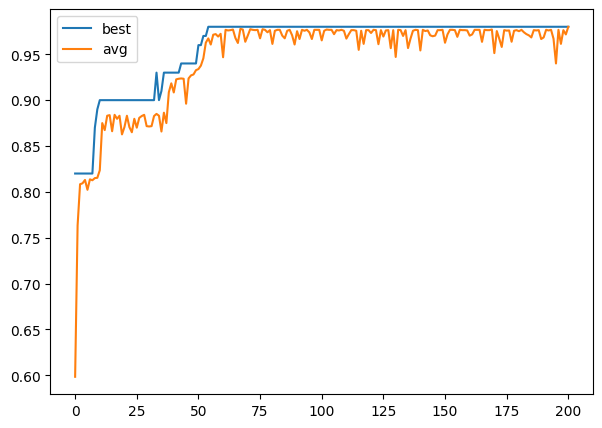

In [8]:
# plotting fitness over time 
balancer.plot_monitor()

In [9]:
# weights after balancing
balancer.result

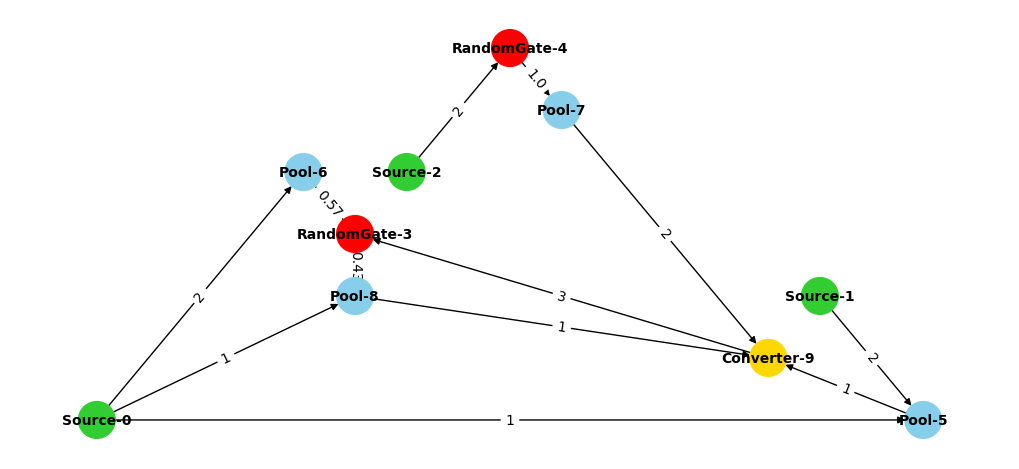

In [10]:
# plot the economy graph with updated weights
balanced_graph = Graph(conf, g.edge_list, weights=balancer.result)
balanced_graph.plot()

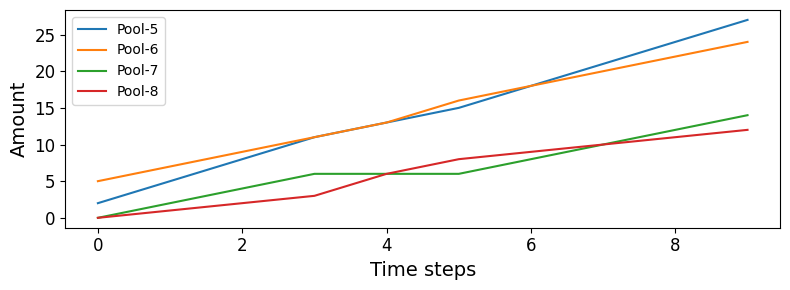

In [11]:
# simulate the economy
for c in balanced_graph.get_nodes_of(n.Converter):
    c.is_auto = False
balanced_graph.simulate(10, agent=agent)
balanced_graph.simulator.plot_monitor(figsize=(8, 3))

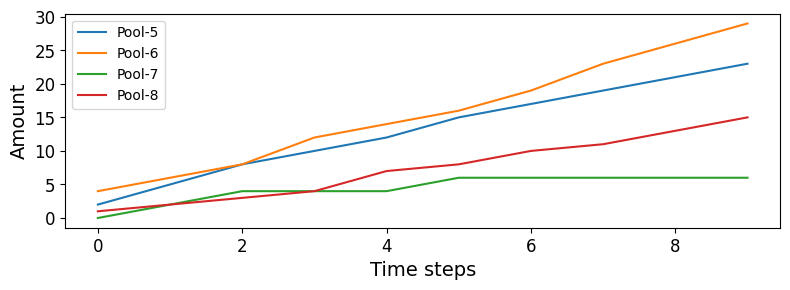

In [12]:
# simulate the economy
for c in balanced_graph.get_nodes_of(n.Converter):
    c.is_auto = False
balanced_graph.simulate(10, agent = Agent(behavior='random'))
balanced_graph.simulator.plot_monitor(figsize=(8, 3))

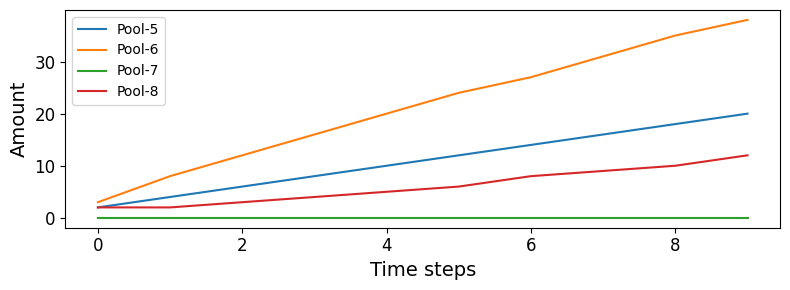

In [13]:
# simulate the economy
for c in balanced_graph.get_nodes_of(n.Converter):
    c.is_auto = False
balanced_graph.simulate(10, agent = Agent(behavior='aggressive'))
balanced_graph.simulator.plot_monitor(figsize=(8, 3))

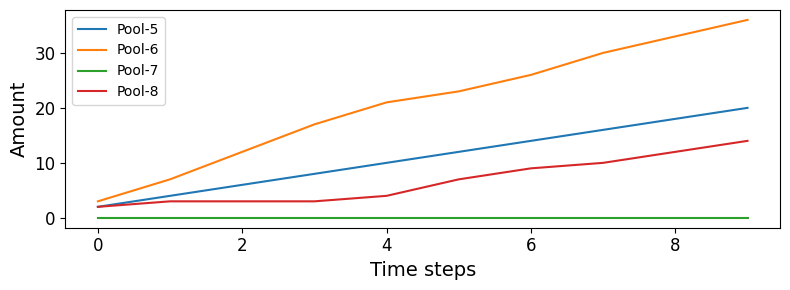

In [14]:
# simulate the economy
for c in balanced_graph.get_nodes_of(n.Converter):
    c.is_auto = False
balanced_graph.simulate(10, agent = Agent(behavior='passive'))
balanced_graph.simulator.plot_monitor(figsize=(8, 3))

---
## Analisis Kode Tidak Berguna (Dead Code Analysis)

Berikut hasil analisis menyeluruh terhadap seluruh file kode project ini.  
File yang diabaikan: folder `compile-here`, `FileTA`, `Tugas_Akhir`, serta semua file PDF/LaTeX.

---

### Ringkasan: Item yang AMAN untuk Dihapus

#### A. File utuh yang bisa dihapus

| File | Alasan |
|------|--------|
| `Gdd/analyze_pdfs.py` | Script standalone, tidak pernah diimport/dipanggil dari mana pun. Fungsinya sudah digantikan oleh `GDDGraphExtractor`. |
| `Gdd/extract_economy.py` | Script standalone, tidak pernah diimport/dipanggil. Superseded oleh `GDDGraphExtractor`. |
| `make_demo.py` | Utility inject kode ke notebook secara otomatis — `demo_agent.ipynb` sudah ada dan dikelola manual, script ini obsolete. |

---

#### B. Kelas yang bisa dihapus

| File | Kelas | Alasan |
|------|-------|--------|
| `geevo/graph.py` | `Graph2` (baris 188–283) | Kelas alternatif yang tidak pernah diinstansiasi atau diimport di mana pun. Duplikasi fungsi `Graph`. |
| `geevo/evolution/balancer.py` | `BalancerV2` (baris 319–477) | Diimport di `demo.ipynb` tapi tidak pernah dipanggil/diinstansiasi. Tidak digunakan di workflow manapun. |
| `geevo/nodes.py` | `FixedPool` (baris 184–201) | Tidak pernah diinstansiasi di notebook, demo, maupun test. Hanya muncul di daftar constraint. |
| `geevo/nodes.py` | `Result` (baris 308–311) | Subclass kosong dari `Pool`, tidak pernah digunakan di mana pun. |

---

#### C. Method/fungsi yang bisa dihapus

| File | Method | Alasan |
|------|--------|--------|
| `geevo/nodes.py` | `Node.init_or_random()` (baris 71–80) | Static method yang tidak pernah dipanggil di mana pun. |
| `geevo/graph.py` | `Graph.update_edge_weights()` (baris 90–95) | Tidak pernah dipanggil. Fungsi serupa sudah ada di `set_edge_weights()`. |
| `geevo/graph.py` | `Graph.update_edge_weights_random()` (baris 127–131) | Tidak pernah dipanggil di mana pun. |
| `geevo/evolution/balancer.py` | `Balancer.get_ind_fitness_single2()` (baris 98–128) | Objective function alternatif yang tidak pernah dipanggil (obj2 tidak ada di workflow). |

---

#### D. Bug yang ditemukan (perlu diperbaiki)

| File | Masalah |
|------|--------|
| `geevo/evolution/balancer.py` | `import matplotlib.pyplot as plt` hilang, padahal `plt` digunakan di method `plot_monitor()` (baris ~313–316 dan ~473–476). Akan error saat dipanggil. |

---

#### E. File yang TETAP DIPERTAHANKAN

| File | Status |
|------|--------|
| `geevo/nodes.py` | Inti — `Edge`, `Node`, `Source`, `Pool`, `Converter`, `RandomGate`, `Drain` semuanya aktif dipakai |
| `geevo/graph.py` | Inti — kelas `Graph` dipakai di semua workflow |
| `geevo/simulation.py` | Inti — `Simulator` dipakai via `Graph.simulate()` |
| `geevo/agent_simulation.py` | Inti — `Agent` & `AgentSimulator` dipakai di notebook ini |
| `geevo/evolution/generator.py` | Inti — `EvolutionaryGraphGeneration` dipakai di semua workflow |
| `geevo/evolution/balancer.py` | Inti — kelas `Balancer` aktif dipakai (minus `BalancerV2`) |
| `geevo/gdd_extractor.py` | Dipakai di notebook ini untuk ekstraksi GDD |
| `update_nb_gdd.py` | Script maintenance notebook — pertahankan |
| `test_integration.py` | Test integrasi utama — pertahankan |
| `demo.ipynb` | Demo inti original — pertahankan |
| `evaluate_metrics.ipynb` | Evaluasi metrik TA — pertahankan |